## Handling Missing Categorical Data

### Overview
Missing categorical data occurs when values in a categorical feature (labels, classes, groups) are absent. Since categories are discrete rather than numeric, statistical imputation methods like mean or median are not applicable.

---

### Common Techniques

#### 1. Mode Imputation
Replace missing values with the most frequent category.

**Use when**
- Missing percentage is low
- Data is not highly imbalanced

**Pros**
- Simple
- Preserves distribution if missing is small

**Cons**
- Can bias toward dominant category

---

#### 2. Add New Category ("Missing" Label)
Create a new category such as `"Missing"` or `"Unknown"`.

**Use when**
- Missingness itself may contain information
- Missing rate is moderate or high

**Pros**
- Keeps missing signal
- Does not distort existing category frequencies

**Cons**
- Adds extra category level

---

#### 3. Predictive Imputation
Predict missing category using other features via models:
- Decision Tree
- Random Forest
- Logistic Regression
- KNN

**Use when**
- Features are correlated
- Dataset is large enough

---

#### 4. Random Sampling Imputation
Fill missing values by randomly sampling from existing category distribution.

**Use when**
- Want to preserve original distribution
- Missing rate is moderate

---

#### 5. Drop Missing Rows
Remove rows where categorical feature is missing.

**Use when**
- Missing percentage very small (<5%)
- Dataset large

---

### When NOT to Impute
Avoid filling if:
- Missing percentage extremely high (>50%)
- Feature not important
- Missingness is systematic and requires domain logic

---

### Strategy Selection Guide

| Missing % | Recommended Method |
|----------|---------------------|
<5% | Drop rows or Mode |
5–20% | Mode or Add category |
20–40% | Add category or Predictive |
>40% | Consider dropping feature |

---

### Best Practice Workflow
1. Check missing percentage
2. Analyze pattern of missingness
3. Try simple method first
4. Compare model performance
5. Use advanced method only if needed

---

### Practical Tip
Always evaluate model performance after imputation. The best method is the one that improves validation results, not the one that sounds most sophisticated.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv('train-missing-cat.csv',usecols=['GarageQual','FireplaceQu','SalePrice'])

In [6]:
df.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [11]:
df.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      0.000000
SalePrice       0.000000
dtype: float64

Text(0, 0.5, 'Number of houses')

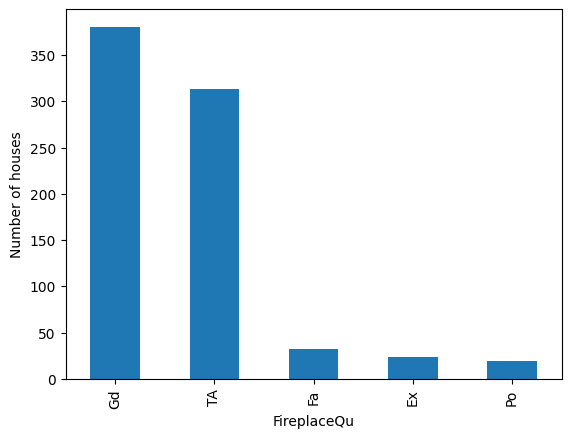

In [13]:
df['FireplaceQu'].value_counts().sort_values(ascending=False).plot.bar()
plt.xlabel('FireplaceQu')
plt.ylabel('Number of houses')

In [14]:
df['FireplaceQu'].mode()

0    Gd
Name: FireplaceQu, dtype: object

In [15]:
df['FireplaceQu'].fillna('Gd', inplace=True)

In [16]:
df.isnull().mean()*100

FireplaceQu    0.0
GarageQual     0.0
SalePrice      0.0
dtype: float64

Text(0, 0.5, 'Number of houses')

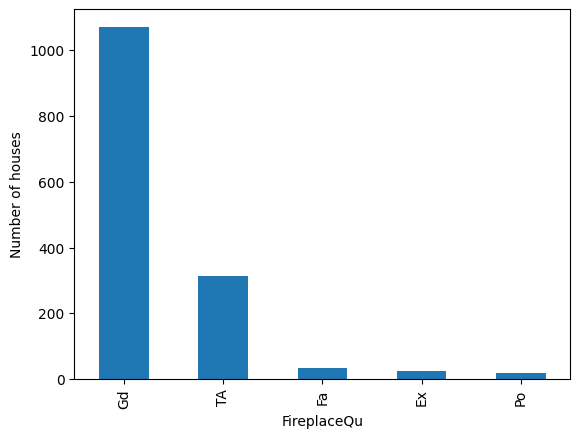

In [17]:
df['FireplaceQu'].value_counts().sort_values(ascending=False).plot.bar()
plt.xlabel('FireplaceQu')
plt.ylabel('Number of houses')

Using Sklearn

In [38]:
from sklearn.model_selection import train_test_split


In [39]:
from sklearn.impute import SimpleImputer

In [40]:
df = pd.read_csv('train-missing-cat.csv',usecols=['GarageQual','FireplaceQu','SalePrice'])

In [41]:
X_train,X_test,y_train,y_test = train_test_split(df.drop(columns=['SalePrice']),df['SalePrice'],test_size=0.2)

In [42]:
imputer = SimpleImputer(strategy='constant',fill_value='Missing')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_train)

d:\AIML\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


In [43]:
imputer.statistics_

array(['Missing', 'Missing'], dtype=object)

Text(0, 0.5, 'Number of houses')

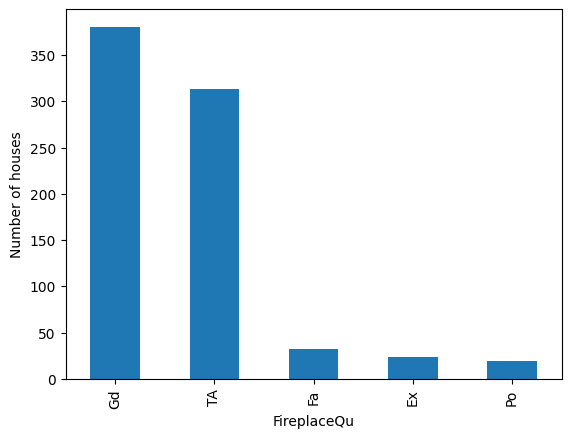

In [44]:
df['FireplaceQu'].value_counts().sort_values(ascending=False).plot.bar()
plt.xlabel('FireplaceQu')
plt.ylabel('Number of houses')

In [46]:
df['FireplaceQu'].isnull().mean()*100

np.float64(47.26027397260274)

Missing values after imputation:
FireplaceQu    0
GarageQual     0
dtype: int64


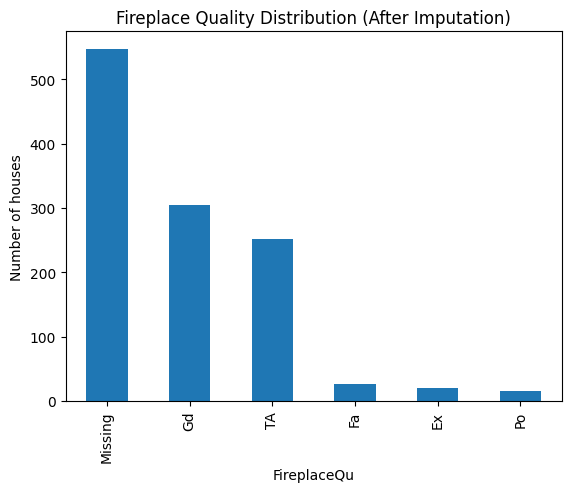

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

# ---------------------------
# 1. Load dataset
# ---------------------------
df = pd.read_csv(
    "train-missing-cat.csv",
    usecols=["GarageQual", "FireplaceQu", "SalePrice"]
)

# ---------------------------
# 2. Separate features & target
# ---------------------------
X = df.drop(columns=["SalePrice"])
y = df["SalePrice"]

# ---------------------------
# 3. Train Test Split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------------------
# 4. Imputer
# ---------------------------
imputer = SimpleImputer(strategy="constant", fill_value="Missing")

# fit on train, transform both
X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns
)

X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns
)

# ---------------------------
# 5. Verify Missing Values Gone
# ---------------------------
print("Missing values after imputation:")
print(X_train.isna().sum())

# ---------------------------
# 6. Plot Cleaned Column
# ---------------------------
X_train["FireplaceQu"].value_counts().plot.bar()
plt.xlabel("FireplaceQu")
plt.ylabel("Number of houses")
plt.title("Fireplace Quality Distribution (After Imputation)")
plt.show()
